# Frequency Response Curve

A **Frequency Response Curve (FRC)** characterizes the steady-state amplitude of a system's response as a function of the excitation frequency. For a given forcing amplitude, it maps out how strongly a system reacts across a range of frequencies. This reveals resonance peaks, the influence of damping, and in the nonlinear case, phenomena such as peak bending, jump phenomena, and the emergence of multiple coexisting solutions.

This notebook investigates a simple dynamical system with a single mass that can move in one direction only. The mass is driven by a periodic force $f_{\text{ex}} = F_0 \cos(\omega t)$. Depending on which physical elements we attach to the mass, like linear springs, linear dampers, or nonlinear elements, the equation of motion takes the form
$$m\ddot{q} + d\dot{q} + cq + f_{\text{nl}}(q, \dot{q}) = f_{\text{ex}},$$
with mass $m$, damping coefficient $d$, linear spring stiffness $c$, and a nonlinear force term $f_{\text{nl}}$. The displacement $q(t)$ describes how the mass moves over time, and we are interested in its steady-state amplitude as a function of the excitation frequency $\omega$.

We will work through the equation of motion term by term, adding one ingredient at a time, and observe how each one shapes the FRC.

**A note on methodology:** For the linear cases, the FRC can be obtained analytically. Once $f_{\text{nl}} \neq 0$, closed-form solutions are generally no longer available. In that case, we use the **Harmonic Balance Method (HBM)**. This solution method assumes a truncated Fourier series as the solution and balances the harmonic coefficients. In combination with **path continuation** methods, it is possible to trace the FRC across the full frequency range, including unstable branches.

## 1. The undamped linear system: <br/> $m\ddot{q} + cq = f_{\text{ex}}$

Before adding damping or nonlinearity, we look at the simplest system capable of oscillating: a single mass on a linear spring, driven by a harmonic force ($d = 0$ and $f_{\text{nl}} = 0$).

The following code block creates a schematic of this system:

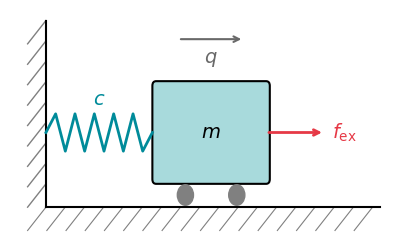

In [111]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from utils.plot_schemes import draw_undamped_linear_system
draw_undamped_linear_system()

### 1.1 Natural frequency

Before looking at the forced response, it is useful to ask: at what frequency does the system naturally want to oscillate, without any external input? This frequency is called the **natural frequency $\omega_0$** and turns out to be the organizing principle of the entire FRC: it is the frequency at which resonance occurs, and the reference against which all excitation frequencies will be normalized.

To find the natural frequency, we consider the **free**, unforced system ($f_{\text{ex}} = 0$):
$$m\ddot{q} + cq = 0.$$
We expect the system to oscillate periodically, so we try a cosine ansatz
$$q(t) = Q_0 \cos(\omega t),$$
where $A$ is the (unknown) amplitude and $\omega$ is the (unknown) frequency.  
Computing the derivatives
$$\dot{q}(t) = -Q_0\omega \sin(\omega t), \qquad \ddot{q}(t) = -Q_0\omega^2 \cos(\omega t)$$
allows to substitute into the equation of motion:
$$-m Q_0\omega^2 \cos(\omega t) + c Q_0 \cos(\omega t) = 0$$
$$Q_0 \cos(\omega t) (c - m\omega^2) = 0$$
Since we are looking for the nontrivial solution ($Q_0\neq 0$, $\cos(\omega t)\neq 0$), the bracket must vanish:
$$c - m\omega^2 = 0 \quad \Longrightarrow \quad \boxed{\omega_0 = \sqrt{\frac{c}{m}}}.$$
The constant $Q_0$ is fixed by initial conditions and does not affect the frequency.  
Note the physical intuition behind this result: a larger stiffness $c$ pulls the mass back more strongly, increasing $\omega_0$; a larger mass $m$ resists acceleration more, decreasing $\omega_0$.

### 1.2 Frequency response

We now switch the forcing back on. Since the system is linear and the input is harmonic, the steady-state response is also harmonic at the same frequency. We can use the same cosine ansatz again:
$$q(t) = Q_0\cos(\omega t), \qquad f_{\text{ex}} = F_0 \cos(\omega t),$$
where $Q_0$ is the unknown steady-state amplitude.  
Substituting into the equation of motion gives
$$- m Q_0 \omega^2 \cos(\omega t) + c Q_0 \cos(\omega t) = F_0 \cos(\omega t).$$
Dividing through by $\cos(\omega t)$ and solving for $Q_0$ gives
$$(c - m\omega^2) Q_0 = F_0 \qquad Q_0 = \frac{F_0}{c - m \omega^2}.$$
The **frequency response function (FRF)** is the ratio of output amplitude to input amplitude
$$H(\omega) = \frac{Q_0}{F_0} = \frac{1}{c - m\omega^2}.$$
Its magnitude
$$|H(\omega)| = \frac{1}{|c - m\omega^2|}$$
diverges when $\omega = \omega_0$: this is **resonance**. With no damping to limit it, the amplitude grows without bound.

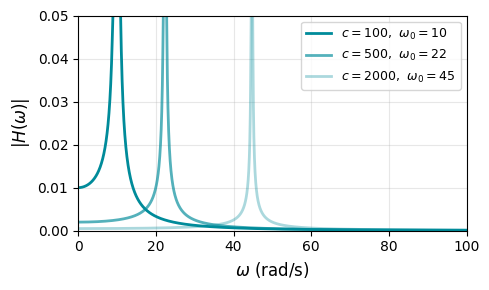

In [112]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

omega = np.linspace(0.1, 150, 5000)
cap = 0.05
m = 1.0

stiffnesses = [100, 500, 2000]
alphas      = [1.0, 0.67, 0.33]

for c, alpha in zip(stiffnesses, alphas):
    omega_0 = np.sqrt(c / m)
    eps = .1
    mask = np.abs(omega - omega_0) > eps
    om_plot = omega[mask]
    H = 1.0 / np.abs(c - m * om_plot**2)
    left  = om_plot < omega_0
    right = om_plot > omega_0
    ax.plot(om_plot[left],  np.clip(H[left],  0, cap), color='#008b9a', lw=2.0, alpha=alpha)
    ax.plot(om_plot[right], np.clip(H[right], 0, cap), color='#008b9a', lw=2.0, alpha=alpha,
            label=rf'$c = {c}$,  $\omega_0 = {omega_0:.0f}$')

ax.set_xlabel(r'$\omega$ (rad/s)', fontsize=12)
ax.set_ylabel(r'$|H(\omega)|$', fontsize=12)
ax.set_xlim(0, 100)
ax.set_ylim(0, cap)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Why do the peaks vary in height?* Stiffer systems have a smaller static compliance $1/c$ and thus a lower absolute amplitude. Normalizing by $c$ will bring all peaks to the same height.

### 1.3 Normalized form and the role of $c$

It is convenient to normalize the excitation frequency by the natural frequency, introducing the **frequency ratio**
$$\Omega = \frac{\omega}{\omega_0}.$$
Substituting $c = m\omega_0^2$ into $|H(\omega)|$ and multiplying through by $c$ gives the **normalized FRF**
$$c \cdot |H(\Omega)| = \frac{1}{|1 - \Omega^2|}.$$
This expression contains neither $c$ nor $m$, it is universal. Changing the stiffness $c$ shifts the resonance peak along the frequency axis (since $\omega_0$ changes), but once you normalize by $\omega_0$, all undamped linear systems collapse onto the same curve with a single peak at $\Omega = 1$.

The following block of code shows the analytically obtained, normalized FRC:

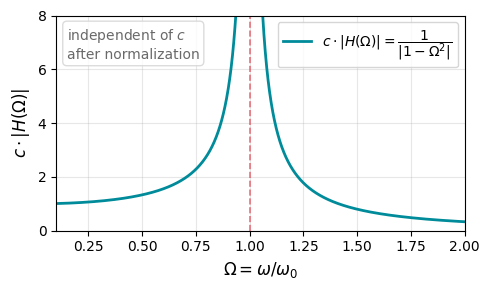

In [113]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# avoid the singularity at Omega=1 by masking a small region around it
Omega = np.linspace(0.1, 2.0, 2000)
eps = 0.02
mask = np.abs(Omega - 1.0) > eps
Om_plot = Omega[mask]

# analytical FRC: c * |H(Omega)| = 1 / |1 - Omega^2|
H_norm = 1.0 / np.abs(1.0 - Om_plot**2)

# cap for display
cap = 8.0
H_plot = np.clip(H_norm, 0, cap)

# split into left and right branch so the vertical asymptote isn't connected
left, right = Om_plot < 1.0, Om_plot > 1.0
ax.plot(Om_plot[left],  H_plot[left],  color='#008b9a', lw=2.0, label=r'$c\cdot|H(\Omega)| = \dfrac{1}{|1-\Omega^2|}$')
ax.plot(Om_plot[right], H_plot[right], color='#008b9a', lw=2.0)

# resonance marker
ax.axvline(1.0, color='#e63946', lw=1.2, ls='--', alpha=0.7)

ax.set_xlabel(r'$\Omega = \omega / \omega_0$', fontsize=12)
ax.set_ylabel(r'$c \cdot |H(\Omega)|$', fontsize=12)
ax.set_xlim(0.1, 2.0)
ax.set_ylim(0, cap)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# annotation: universal curve
ax.text(0.15, cap * 0.8, 'independent of $c$\nafter normalization', fontsize=10, color='dimgray', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

## 2. The damped linear system: <br/> $m\ddot{q} + d\dot{q} + cq = f_{\text{ex}}$

We now add a linear viscous damper. The equation of motion is still linear.

The following block of code shows a schematic of the system:

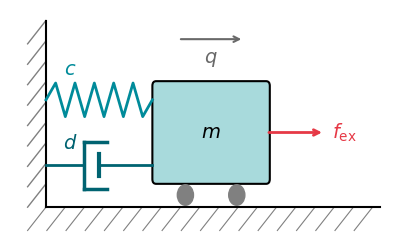

In [115]:
from utils.plot_schemes import draw_damped_linear_system

draw_damped_linear_system()

### 2.1 Frequency response with damping

In the undamped case, we could use a cosine ansatz because the response was perfectly in phase with the forcing. With damping present, this is no longer true. The damper term $d\dot{q}$ introduces a velocity-dependent force which is $90°$ out of phase with the displacement. The response therefore contains both an in-phase (cosine) and an out-of-phase (sine) component, which makes a pure cosine ansatz cumbersome.  
Instead, we use the **complex exponential ansatz** 
$$q(t) = Q_0 e^{i\omega t}, \qquad f_{\text{ex}} = F_0 e^{i\omega t},$$
where $Q_0$ is now allowed to be complex. Its magnitude $|Q_0|$ gives the response amplitude, and its argument $\arg(Q_0)$ gives the phase lag relative to the forcing. Computing the derivatives, substituting into the equation of motion and dividing through by $e^{i\omega t}$ yields
$$-m\omega^2 Q_0 + i\, d\omega Q_0 + c Q_0 = F_0$$
$$(c - m\omega^2 + i\, d\omega) Q_0 = F_0.$$
Solving for $Q_0$ gives the FRF
$$H(\omega) = \frac{Q_0}{F_0} = \frac{1}{(c - m\omega^2) + i\, d\omega}.$$
Unlike the undamped case, $H(\omega)$ is now complex-valued. It carries both amplitude and phase information. Since we are primarily interested in the in the amplitude of the steady-state response, we take the magnitude. For a complex numer $1/(a+i\, b)$, the magnitude is $1/\sqrt(a^2 + b^2)$, so:
$$|H(\omega)| = \frac{1}{\sqrt{(c - m\omega^2)^2 + (d\omega)^2}}.$$
Note that the damper term $(d\omega)^2$ is always positive. It can never be zero for $\omega >0$. This is why the FRC no longer diverges at resonance.

### 2.2 Normalized form

Substituting $c=m\omega_0^2, \Omega = \omega/\omega_0$, and multiplying through by $c$ exactly as in Section 1.3, the denominator becomes:
$$\sqrt{(c - m\omega^2)^2 + \left(d\omega\right)^2} 
= c\sqrt{(1-\Omega^2)^2 + \left(\frac{d\omega}{c}\right)^2}.$$
The remaining factor $d\omega/c$ can be rewritten using $\omega=\Omega\omega_0$ and $\omega_0/c=1/\sqrt{mc}$:
$$\frac{d\omega}{c} = \frac{d\Omega\omega_0}{c} = \underbrace{\frac{d}{\sqrt{mc}}}_{=:2\zeta}\Omega,$$
where we define the **damping ratio $\zeta$**. It compares the actual damping to the **critical damping** $d_{\text{crit}} = 2\sqrt{mc}$ at which the system ceases to oscillate.  
Putting it all together:
$$c \cdot |H(\Omega)| = \frac{1}{\sqrt{(1 - \Omega^2)^2 + (2\zeta\Omega)^2}}.$$
For $\zeta < 1$ (underdamped), the system still oscillates and the FRC shows a peak. For $\zeta \geq 1$, the system returns to equilibrium without oscillating and no resonance peak appears.

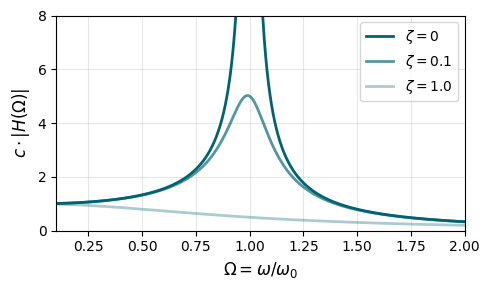

In [116]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

Omega_damped = np.linspace(0.05, 2.0, 3000)
cap = 8.0

zetas = [0, 0.1, 1.]
alphas = [1.0, 0.67, 0.33]

for zeta, alpha in zip(zetas, alphas):
    H = 1.0 / np.sqrt((1 - Omega_damped**2)**2 + (2 * zeta * Omega_damped)**2)
    ax.plot(Omega_damped, np.clip(H, 0, cap), color='#006371', lw=2.0, alpha=alpha, label=rf'$\zeta = {zeta}$')

ax.set_xlabel(r'$\Omega = \omega / \omega_0$', fontsize=12)
ax.set_ylabel(r'$c \cdot |H(\Omega)|$', fontsize=12)
ax.set_xlim(0.1, 2.0)
ax.set_ylim(0, cap)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Peak amplitude and resonance frequency

With damping present, the peak of the FRC no longer sits exactly at $\Omega = 1$. Differentiating $c\cdot |H(\Omega)|$ with respect to $\Omega$ and setting the result to zero gives the **damped resonance frequency**
$$\Omega_{\text{res}} = \sqrt{1 - 2\zeta^2},$$
which is slightly below 1 and vanishes for $\zeta \geq 1/\sqrt{2} \approx 0.707$. Beyond this value, the FRC has no peak at all and the system is too heavily damped to resonate.  
The corresponding **peak amplitude** is
$$c \cdot |H|_{\text{max}} = \frac{1}{2\zeta\sqrt{1 - \zeta^2}}.$$
For small damping ($\zeta \ll 1$), this simplifies to the useful approximation
$$c \cdot |H|_{\text{max}} \approx \frac{1}{2\zeta}.$$
This means doubling the damping ratio halves the peak amplitude, which is a direct and practically important relationship.

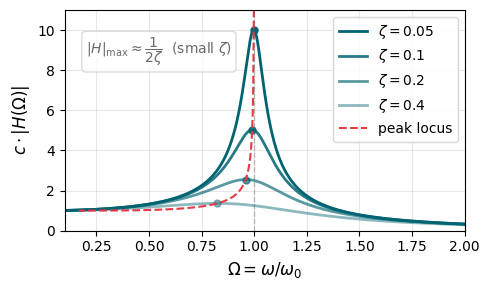

In [117]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

Omega = np.linspace(0.05, 2.0, 3000)
cap = 11.0

zetas = [0.05, 0.1, 0.2, 0.4]
alphas = [1.0, 0.85, 0.65, 0.45]

for zeta, alpha in zip(zetas, alphas):
    H = 1.0 / np.sqrt((1 - Omega**2)**2 + (2 * zeta * Omega)**2)
    ax.plot(Omega, np.clip(H, 0, cap), color='#006371', lw=2.0, alpha=alpha, label=rf'$\zeta = {zeta}$')
    Om_res = np.sqrt(1 - 2 * zeta**2)
    H_peak = 1.0 / np.sqrt((1 - Om_res**2)**2 + (2 * zeta * Om_res)**2)
    ax.plot(Om_res, H_peak, 'o', color='#006371', ms=5, alpha=alpha)

# --- analytical peak locus ---
zeta_locus = np.linspace(0.01, 1 / np.sqrt(2) - 0.01, 300)
Om_locus   = np.sqrt(1 - 2 * zeta_locus**2)
H_locus    = 1.0 / (2 * zeta_locus * np.sqrt(1 - zeta_locus**2))
ax.plot(Om_locus, np.clip(H_locus, 0, cap),
        color='#e63946', lw=1.5, ls='--', label='peak locus')

# resonance marker
ax.axvline(1.0, color='dimgray', lw=1.0, ls='--', alpha=0.4)

ax.annotate(r'$|H|_{\max} \approx \dfrac{1}{2\zeta}$  (small $\zeta$)', xy=(.2, cap * 0.8), fontsize=10, color='dimgray', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))

ax.set_xlabel(r'$\Omega = \omega / \omega_0$', fontsize=12)
ax.set_ylabel(r'$c \cdot |H(\Omega)|$', fontsize=12)
ax.set_xlim(0.1, 2.0)
ax.set_ylim(0, cap)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As $\zeta$ varies continuously from 0 to $1/\sqrt{2}$, the peak traces out a curve in the $(\Omega, |H|)$ plane, shown as the dashed red line in the plot. Each point on this curve is the tip of the FRC for one particular damping ratio. The locus starts at $(1, \infty)$ for $\zeta \rightarrow 0$ (undamped, infinite peak exactly at $\Omega=1$) and ends at $(0, 1)$ for $\zeta \rightarrow 1/\sqrt{2}$ (peak just disappears at zero frequency).

*Why does the peak shift left?* The damper exerts a force proportional to velocity, $f_d =d\dot{q}$. Velocity is 90° out of phase with both displacement and acceleration, so the damping force partially opposes the motion and effectively reduces the net restoring force acting on the mass, as if the system was slightly softer than it actually is, shifting the peak to the left.  
We can also look at the mechanism in terms of energy. In the undamped case, the total energy of the system is largest when the excitation hits the natural frequency $\omega_0$: spring and inertia forces cancel exactly, the system offers no net resistance, and the forcing can build up amplitude without bound. This is resonance.  
Once a damper is present, it continuously withdraws energy from the system, and the faster the mass moves, the more energy it removes. The sweet spot, that is where the balance between energy input from the forcing and energy dissipation by the damper produces the largest steady-state amplitude, therefore shifts to a frequency slightly below $\omega_0$​.  
Mathematically, this is reflected in $\Omega_\text{res} = \sqrt{1 - 2\zeta^2}$​: the peak moves left as $\zeta$ increases, and disappears entirely at $\zeta = 1/\sqrt{2}$​, where the damper dissipates energy so aggressively that no frequency can sustain a resonance peak at all.

### 2.4 Estimating damping from an experimental FRC: the half-power bandwidth

The peak amplitude $c\cdot|H|_\text{max} \approx \frac{1}{2\zeta}$​ allows $\zeta$ to be read off directly from the FRC, but only if $c$ is known, since the y-axis is scaled by $c$. In experimental practice, however, $c$ is often unavailable. The **half-power bandwidth method** offers an alternative that requires only frequency information: at the two **half-power frequencies** $\Omega_1$​ and $\Omega_2$, where the amplitude drops to $|H|_\text{peak}/\sqrt{2}$, it can be shown that
$$\zeta \approx \frac{\Omega_2 - \Omega_1}{2}.$$
This way it is possible to identify the damping of a structure without knowing any of its physical parameters.


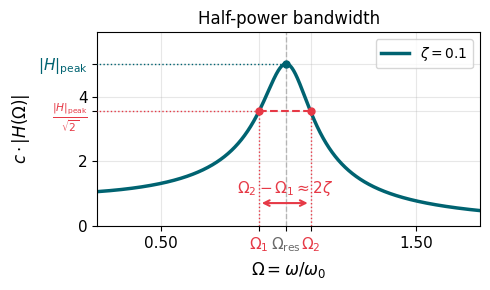

In [118]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
Omega = np.linspace(0.05, 2.0, 3000)
cap = 6.0

zeta = 0.1
H_hi = 1.0 / np.sqrt((1 - Omega**2)**2 + (2 * zeta * Omega)**2)
ax.plot(Omega, np.clip(H_hi, 0, cap), color='#006371', lw=2.5, label=rf'$\zeta = {zeta}$')

Om_res = np.sqrt(1 - 2 * zeta**2)
H_peak = 1.0 / np.sqrt((1 - Om_res**2)**2 + (2 * zeta * Om_res)**2)
H_half = H_peak / np.sqrt(2)

def eq(O): return 1.0 / np.sqrt((1 - O**2)**2 + (2 * zeta * O)**2) - H_half
Om1 = brentq(eq, 0.5, Om_res - 0.001)
Om2 = brentq(eq, Om_res + 0.001, 1.8)

ax.hlines(H_half, Om1, Om2, color='#e63946', lw=1.5, ls='--', zorder=4)
ax.vlines([Om1, Om2], 0, H_half, color='#e63946', lw=1.0, ls=':', zorder=4)
ax.axvline(Om_res, color='dimgray', lw=1.0, ls='--', alpha=0.4)
ax.hlines(H_half, 0, Om1, color='#e63946', lw=1.0, ls=':', zorder=4)
ax.hlines(H_peak, 0, Om_res, color='#006371', lw=1.0, ls=':', zorder=4)
ax.plot(Om_res, H_peak, 'o', color='#006371', ms=5, zorder=5)
ax.plot([Om1, Om2], [H_half, H_half], 'o', color='#e63946', ms=5, zorder=5)
ax.annotate('', xy=(Om2, H_half * 0.2), xytext=(Om1, H_half * 0.2), arrowprops=dict(arrowstyle='<->', color='#e63946', lw=1.5))
ax.text((Om1 + Om2) / 2, H_half * 0.2 + 0.15, r'$\Omega_2 - \Omega_1 \approx 2\zeta$', ha='center', va='bottom', fontsize=11, color='#e63946')

# --- custom ticks instead of ax.text labels ---
# x-axis: keep 0.5, 1.5, 2.0 as neutral ticks, add Om1, Om_res, Om2
x_base    = [0.5, 1.5, 2.0]
x_special = [Om1, Om_res, Om2]
x_labels  = [f'{v:.2f}' for v in x_base] + [r'$\Omega_1$', r'$\Omega_\mathrm{res}$', r'$\Omega_2$']
ax.set_xticks(x_base + x_special)
ax.set_xticklabels(x_labels, fontsize=11)
# color just the special ones
for tick, val in zip(ax.get_xticklabels(), x_base + x_special):
    if val in x_special: tick.set_color('#e63946' if val != Om_res else 'dimgray')

# y-axis: keep 0, 2, 4 as neutral ticks, add H_half and H_peak
y_base    = [0, 2, 4]
y_special = [H_half, H_peak]
y_labels  = ['0', '2', '4'] + [r'$\frac{|H|_\mathrm{peak}}{\sqrt{2}}$', r'$|H|_\mathrm{peak}$']
ax.set_yticks(y_base + y_special)
ax.set_yticklabels(y_labels, fontsize=11)
for tick, val in zip(ax.get_yticklabels(), y_base + y_special):
    if val in y_special: tick.set_color('#e63946' if val == H_half else '#006371')

ax.set_xlabel(r'$\Omega = \omega / \omega_0$', fontsize=12)
ax.set_ylabel(r'$c \cdot |H(\Omega)|$', fontsize=12)
ax.set_title('Half-power bandwidth', fontsize=12)
ax.set_xlim(0.25, 1.75)
ax.set_ylim(0, cap)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Nonlinear systems: <br/> $m\ddot{q} + d\dot{q} + cq + f_{\text{nl}} = f_{\text{ex}}$

So far, all systems we considered were linear, meaning the equation of motion contains $q$ and $\dot{q}$ only to the first power. This had a key consequence: the superposition principle holds, and we could solve for the response analytically using a single harmonic ansatz.

Once we introduce a nonlinear force term $f_{\text{nl}}(q, \dot{q})$, both of these properties are lost. The response to a harmonic input is no longer purely harmonic. Higher harmonics are generated, and the amplitude of the response depends on the forcing amplitude $F_0$ in a nontrivial way. The FRC is no longer a fixed curve, it changes shape as $F_0$ changes.  

To compute the FRC in the nonlinear case, we use the **Harmonic Balance Method (HBM)**. Instead of solving the differential equation directly, we assume a truncated Fourier series as the solution,
$$q(t) \approx \sum_{k=0}^{N} a_k \cos(k\omega t) + b_k \sin(k\omega t),$$
substitute it into the equation of motion, and require that each harmonic coefficient balances independently. This converts the differential equation into a (nonlinear) algebraic system for the coefficients $a_k$, $b_k$, which can be solved numerically.

To trace the full FRC, including **unstable branches** that a direct simulation would never reach, HBM is combined with **path continuation**: starting from a known solution, small predictor-corrector steps follow the solution curve through parameter space, around folds and bifurcation points.

### 3.1 The Duffing nonlinearity: <br/> $f_{\text{nl}} = \alpha q^3$

The **Duffing oscillator** extends the linear spring with a cubic term:
$$m\ddot{q} + d\dot{q} + cq + \alpha q^3 = f_{\text{ex}}.$$
The nonlinear spring force $f_{\text{nl}} = \alpha q^3$ grows faster than linearly with displacement. For $\alpha > 0$, the spring becomes stiffer as the mass moves further from equilibrium. This is called a **hardening** or **stiffening** nonlinearity (for $\alpha < 0$, it softens).

A real-world example of this is the membrane stiffening of a trampoline: the further the surface is deformed, the stronger the restoring force pulling it back - that's the fun of it!

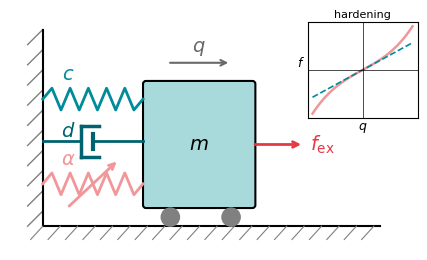

In [120]:
from utils.plot_schemes import draw_nonlinear_Duffing_system

draw_nonlinear_Duffing_system()

#### Effect on the FRC

In the linear case, the resonance peak sits at a fixed frequency $\omega_0$, regardless of forcing amplitude. The Duffing nonlinearity breaks this: because the effective stiffness depends on the response amplitude, the resonance frequency shifts with amplitude. For hardening ($\alpha > 0$), larger amplitudes experience a stiffer spring, and the peak **leans to the right**. For softening ($\alpha < 0$), the peak leans to the left.

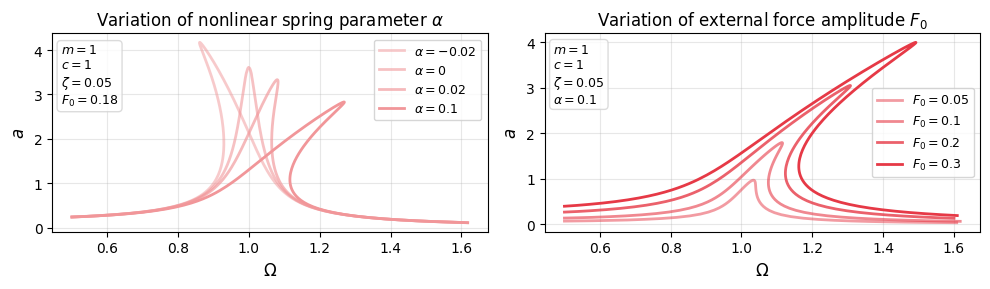

In [124]:
import json
import matplotlib.pyplot as plt
from collections import Counter


with open("../data/Duffing_data.json", "r") as f:
    entries = json.load(f)
mu    = entries[0]['mu']
zeta  = entries[0]['zeta']
kappa = entries[0]['kappa']
gamma_vals = [entry['gamma'] for entry in entries]
P_vals     = [entry['P'] for entry in entries]
gamma_fixed = Counter(gamma_vals).most_common(1)[0][0]
P_fixed     = Counter(P_vals).most_common(1)[0][0]
gamma_group = sorted([e for e in entries if e['P'] == P_fixed], key=lambda e: e['gamma'])
P_group = [e for e in entries if e['gamma'] == gamma_fixed and e['P'] != P_fixed]

fig, (ax_gamma, ax_F0) = plt.subplots(1, 2, figsize=(10, 3))

for entry in gamma_group:
    Om = entry['data'][0]
    a  = entry['data'][1]
    ax_gamma.plot(Om, a, color='#f19699', lw=2.0, alpha=0.5 + 0.5 * abs(entry['gamma'] - min([e['gamma'] for e in gamma_group])) / max(1e-12, (max([e['gamma'] for e in gamma_group]) - min([e['gamma'] for e in gamma_group]))), label=rf'$\alpha = {entry["gamma"]}$')
ax_gamma.set_xlabel(r'$\Omega$', fontsize=12)
ax_gamma.set_ylabel(r'$a$', fontsize=12)
ax_gamma.set_title(r'Variation of nonlinear spring parameter $\alpha$', fontsize=12)
ax_gamma.grid(True, alpha=0.3)
ax_gamma.legend(fontsize=9, loc='best')
textstr = '\n'.join((rf'$m = {mu}$', rf'$c = {kappa}$', rf'$\zeta = {zeta}$', rf'$F_0 = {P_fixed}$'))
ax_gamma.text(0.02, 0.95, textstr, transform=ax_gamma.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))

for entry in P_group:
    Om = entry['data'][0]
    a  = entry['data'][1]
    ax_F0.plot(Om, a, color='#e63946', lw=2.0, alpha=0.5 + 0.5 * abs(entry['P'] - min([e['P'] for e in P_group])) / max(1e-12, (max([e['P'] for e in P_group]) - min([e['P'] for e in P_group]))), label=rf'$F_0 = {entry["P"]}$')
ax_F0.set_xlabel(r'$\Omega$', fontsize=12)
ax_F0.set_ylabel(r'$a$', fontsize=12)
ax_F0.set_title(r'Variation of external force amplitude $F_0$', fontsize=12)
ax_F0.grid(True, alpha=0.3)
ax_F0.legend(fontsize=9, loc='best')
textstr = '\n'.join((rf'$m = {mu}$', rf'$c = {kappa}$', rf'$\zeta = {zeta}$', rf'$\alpha = {gamma_fixed}$'))
ax_F0.text(0.02, 0.95, textstr, transform=ax_F0.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

#### Multivaluedness and the jump phenomenon

Applying HBM with a single harmonic ansatz $q(t) \approx Q\cos(\omega t)$ and balancing the fundamental harmonic leads to an implicit equation relating $Q$ and $\omega$ — which turns out to be **cubic in $Q^2$**. A cubic equation can have up to three real solutions, meaning that for a range of excitation frequencies, three different steady-state amplitudes are possible simultaneously.

Of these three coexisting solutions, two are **stable** and one is **unstable**. The unstable branch sits between the two stable ones and is never observed in a direct simulation or experiment — the system always settles onto one of the stable branches depending on its history.

This multivaluedness gives rise to the **jump phenomenon** and **hysteresis**: 
- Sweeping the excitation frequency **upward**, the system follows the upper stable branch until it runs out at a **fold bifurcation point**, then jumps abruptly down to the lower branch.
- Sweeping **downward**, it follows the lower branch until a second fold point, then jumps back up.

The two jump points are at different frequencies, so the system traces out a different path depending on the sweep direction:

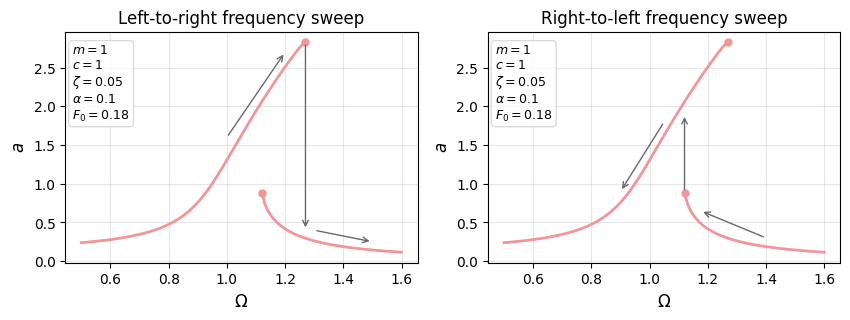

In [126]:
import json
import matplotlib.pyplot as plt
import numpy as np


with open("../data/Duffing_stable_branches.json", "r") as f:
    entries = json.load(f)
mu    = entries[0]['mu']
zeta  = entries[0]['zeta']
kappa = entries[0]['kappa']
gamma = entries[0]['gamma']
P_vals = entries[0]['P']

fig, (ax_ltr, ax_rtl) = plt.subplots(1, 2, figsize=(10, 3))

Om_lower = entries[0]['data'][0]
a_lower  = entries[0]['data'][1]
Om_upper = entries[1]['data'][0]
a_upper  = entries[1]['data'][1]
ax_ltr.plot(Om_lower, a_lower, color='#f19699', lw=2.0)
ax_ltr.plot(Om_lower[np.argmax(a_lower)], max(a_lower), 'o', color='#f19699', ms=5)
ax_ltr.annotate("", xytext=(1., 1.6), xy=(1.2, 2.7), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_ltr.annotate("", xytext=(Om_lower[np.argmax(a_lower)], max(a_lower)), xy=(Om_lower[np.argmax(a_lower)], 0.4), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_ltr.annotate("", xytext=(1.3, .4), xy=(1.5, .25), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_ltr.plot(Om_upper, a_upper, color='#f19699', lw=2.0)
ax_ltr.plot(Om_upper[np.argmax(a_upper)], max(a_upper), 'o', color='#f19699', ms=5)
textstr = '\n'.join((rf'$m = {mu}$', rf'$c = {kappa}$', rf'$\zeta = {zeta}$', rf'$\alpha = {gamma}$', rf'$F_0 = {P_vals}$'))
ax_ltr.text(0.02, 0.95, textstr, transform=ax_ltr.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))
ax_ltr.set_title('Left-to-right frequency sweep', fontsize=12)
ax_ltr.set_xlabel(r'$\Omega$', fontsize=12)
ax_ltr.set_ylabel(r'$a$', fontsize=12)
ax_ltr.grid(True, alpha=0.3)

ax_rtl.plot(Om_lower, a_lower, color='#f19699', lw=2.0)
ax_rtl.plot(Om_lower[np.argmax(a_lower)], max(a_lower), 'o', color='#f19699', ms=5)
ax_rtl.annotate("", xytext=(1.4, .3), xy=(1.175, .65), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_rtl.annotate("", xytext=(Om_upper[np.argmax(a_upper)], max(a_upper)), xy=(Om_upper[np.argmax(a_upper)], 1.9), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_rtl.annotate("", xytext=(1.05, 1.8), xy=(.9, .9), arrowprops=dict(arrowstyle="->", color='dimgrey'))
ax_rtl.plot(Om_upper, a_upper, color='#f19699', lw=2.0)
ax_rtl.plot(Om_upper[np.argmax(a_upper)], max(a_upper), 'o', color='#f19699', ms=5)
textstr = '\n'.join((rf'$m = {mu}$', rf'$c = {kappa}$', rf'$\zeta = {zeta}$', rf'$\alpha = {gamma}$', rf'$F_0 = {P_vals}$'))
ax_rtl.text(0.02, 0.95, textstr, transform=ax_rtl.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))
ax_rtl.set_title('Right-to-left frequency sweep', fontsize=12)
ax_rtl.set_xlabel(r'$\Omega$', fontsize=12)
ax_rtl.set_ylabel(r'$a$', fontsize=12)
ax_rtl.grid(True, alpha=0.3)

### 3.2 The Jenkins element: <br/> $f_{\text{nl}} = $ friction (stick-slip)

The **Jenkins element** is a simple model for dry friction. It consists of a linear spring (stiffness $k$) in series with a Coulomb friction slider (slip force $\mu N$). The element alternates between two phases:
- **Stick phase:** the slider does not slip, and the Jenkins spring adds its stiffness $k$ to the total restoring force. The element behaves like a linear spring.
- **Slip phase:** the slider moves at constant friction force $\mu N$, and the Jenkins spring no longer contributes additional stiffness. The element dissipates energy.

Whether the element sticks or slips depends on the current force in the Jenkins spring, which in turn depends on the displacement history. This makes the Jenkins element **amplitude-dependent and hysteretic**: the force-displacement curve forms a closed loop (a hysteresis loop) over one cycle, whose area equals the energy dissipated per cycle.

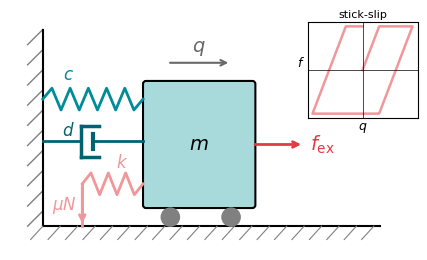

In [127]:
from utils.plot_schemes import draw_nonlinear_Jenkins_system

draw_nonlinear_Jenkins_system()

#### Effect on the FRC

To interpret the effect on the FRC, it is helpful to compare three limiting cases: *stick*, *free*, and *slip*.

In the **stick regime**, the Jenkins element does not slip and behaves like an additional linear spring. In a simplified single-harmonic view, the response amplitude is
$$
Q_{\text{stick}}(\Omega)=\frac{F_0}{-\Omega^2 m + i\Omega \zeta + c + k}.
$$
Since this case forms the basis for the normalization of the plot and dissipation is very small ($\zeta=0.01$), the sharp peak is located close to $\Omega=1$ and resembles that of a lightly damped linear system.

In the **free case**, the contact is effectively inactive, and the amplitude is given by
$$
Q_{\text{free}}(\Omega)=\frac{F_0}{-\Omega^2 m + i\Omega \zeta + c}.
$$
The system is softer than in the stick case ($c < c+k$), so the resonance shifts to lower frequencies. This explains why the peak appears significantly to the left of the stick curve.

The **slip case** is modeled using the first harmonic of the Coulomb friction force:
$$
Q_{\text{slip}}(\Omega)=\frac{1}{-\Omega^2 m + i\Omega \zeta + c}\left(F_0 + \frac{4}{\pi}\mu N\right).
$$
Here, the contact no longer contributes stiffness, so the resonance frequency coincides approximately with that of the free system. This explains why both curves peak at nearly the same lower frequency. However, unlike the true dissipative action of friction, this harmonic approximation appears as an additional forcing term. As a result, the slip response can reach larger amplitudes than the free system, even though no additional stiffness is present.

The **nonlinear Jenkins response** (stick-slip) transitions between these limits. At low amplitudes, the motion remains in stick and the response follows the stiff linear system. Near resonance, the displacement becomes large enough to exceed the friction limit force, leading to intermittent slip. In the time domain, this corresponds to force plateaus where the spring force is clipped at the friction limit.  
This reduces the effective stiffness and introduces amplitude-dependent energy dissipation. Consequently, the frequency response curve exhibits a characteristic **softening behavior**: the resonance peak bends toward lower frequencies and is significantly flattened compared to the purely linear stick case.

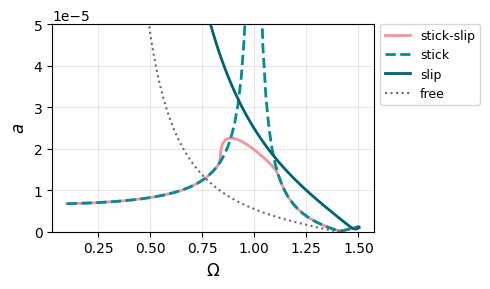

In [128]:
import json
import matplotlib.pyplot as plt


with open("../data/Jenkins_data.json", "r") as f:
    entries = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# plot entry with force == 40
entry = next(e for e in entries if e['force'] == 40)
ax.plot(entry['freq_ratio'], entry['Q_nl'], color='#f19699', lw=2.0, label='stick-slip')
ax.plot(entry['freq_ratio'], entry['Q_stick'], color='#008b9a', lw=2.0, ls='--', label='stick')
ax.plot(entry['freq_ratio'], entry['Q_slip'], color='#006371', lw=2.0, label='slip')
ax.plot(entry['freq_ratio'], entry['Q_free'], color='dimgray', lw=1.5, ls=':', label='free')

ax.set_xlabel(r'$\Omega$', fontsize=12)
ax.set_ylabel(r'$a$', fontsize=12)
ax.set_ylim(0, 5e-5)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.0, 1.03))
plt.tight_layout()
plt.show()



#### Multiple peaks in the FRC

To further investigate the nonlinear behavior, the system parameters (mass, stiffness, damping, friction limit, etc.) are kept fixed while only the forcing amplitude ($F_0$) is varied.

At low forcing levels ($F_0 = 10$), the response closely follows the linear *stick* solution. The Jenkins element remains almost entirely in the stick regime, and the frequency response curve (FRC) exhibits a sharp peak near $\Omega \approx 1$, with only slight clipping at the top due to the onset of frictional limits.

As the forcing amplitude increases ($F_0 = 30, 50$), the peak gradually shifts to lower frequencies and becomes less sharp. This reflects the increasing influence of slip: the effective stiffness is reduced and energy is dissipated through friction, leading to the characteristic softening behavior.

At higher amplitudes ($F_0 \geq 70$), a qualitative change occurs. In addition to the main resonance peak (now shifted to lower frequencies), new peaks emerge on the left-hand side of the FRC. Initially, these appear as small secondary maxima, but with increasing $F_0$ they grow in amplitude and can eventually surpass the original main peak. At even larger forcing levels, multiple additional peaks can be observed.

These new peaks are not associated with additional linear modes of the system. Instead, they arise from the strongly nonlinear stick–slip motion, which introduces higher harmonics into the response. Since the Harmonic Balance Method (HBM) includes multiple harmonics (here three), these higher-frequency components can themselves resonate with the system. This leads to so-called **superharmonic resonances**, which appear at excitation frequencies below the primary resonance.

As the forcing amplitude increases, the stick–slip transitions become more pronounced, generating stronger higher harmonics. Consequently, these secondary resonances become more visible and eventually dominate the response.

In summary, the emergence of additional peaks in the FRC is a direct manifestation of nonlinear harmonic interactions induced by frictional contact. They are neither new modes nor artifacts, but genuine nonlinear resonance phenomena captured by the multi-harmonic HBM formulation.


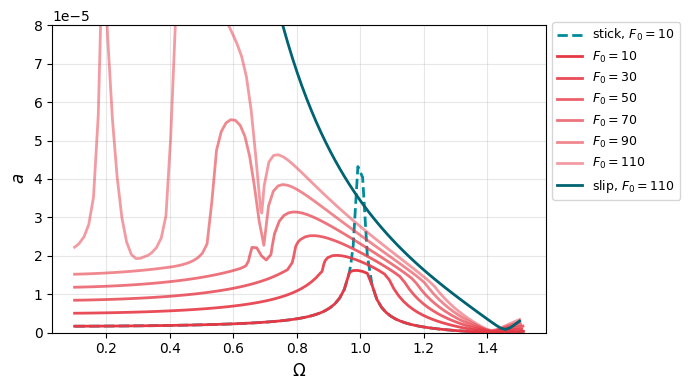

In [130]:
import json
import matplotlib.pyplot as plt


with open("../data/Jenkins_data.json", "r") as f:
    entries = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

for i, entry in enumerate(entries):
    if entry['force'] == 10:
        ax.plot(entry['freq_ratio'], entry['Q_stick'], color='#008b9a', lw=2.0, ls='--', label=f'stick, $F_0 = {entry["force"]}$')
        
    if entry['force'] % 20:
        ax.plot(entry['freq_ratio'], entry['Q_nl'], color='#e63946', lw=2.0, alpha=1 - 0.05*i, label=rf'$F_0 = {entry["force"]}$')
    if entry['force'] == 110:
        ax.plot(entry['freq_ratio'], entry['Q_slip'], color='#006371', lw=2.0, label=f'slip, $F_0 = {entry["force"]}$')
    
ax.set_xlabel(r'$\Omega$', fontsize=12)
ax.set_ylabel(r'$a$', fontsize=12)
ax.set_ylim(0, 8e-5)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1., 1.03))
plt.tight_layout()
plt.show()

#### Role of Higher Harmonics and Nonlinear Coupling

To better understand the origin of the additional peaks, it is instructive to examine the contribution of individual harmonics in the HBM solution.

At low forcing amplitudes, the response is almost purely harmonic, and the total RMS amplitude is nearly identical to the amplitude of the fundamental harmonic. This indicates that the system behaves essentially linearly, with negligible contributions from higher harmonics.

As the forcing amplitude increases ($F_0 \gtrsim 50$), the situation changes: significant contributions from higher harmonics (in particular the third harmonic) appear in the response. These contributions become especially pronounced in the additional peaks that emerge at lower excitation frequencies.

A key observation is that, although these peaks are clearly associated with higher harmonics, the fundamental harmonic also exhibits a large amplitude in the same frequency range. This may seem counterintuitive at first, as one might expect these peaks to be purely “superharmonic” in nature.

The reason lies in the strong nonlinear coupling introduced by the Jenkins element. In the Harmonic Balance formulation, all harmonics are solved simultaneously as part of a coupled system. The friction-induced nonlinearity generates higher harmonics, but it also couples them back into the fundamental response.

In particular, when a higher harmonic (e.g. the third harmonic) approaches resonance with the system, it can strongly amplify the overall motion. Through the nonlinear force interaction, this amplification feeds back into the fundamental harmonic, causing it to grow as well.

As a result, the additional peaks in the frequency response are not purely associated with a single harmonic. Instead, they represent **coupled nonlinear resonance states**, in which multiple harmonics interact and reinforce each other.

This explains why the fundamental harmonic remains dominant in the total amplitude, even in regions where higher harmonics play a crucial role in triggering the resonance. The higher harmonics effectively “activate” these additional peaks, while the fundamental harmonic carries a significant portion of the observable response.


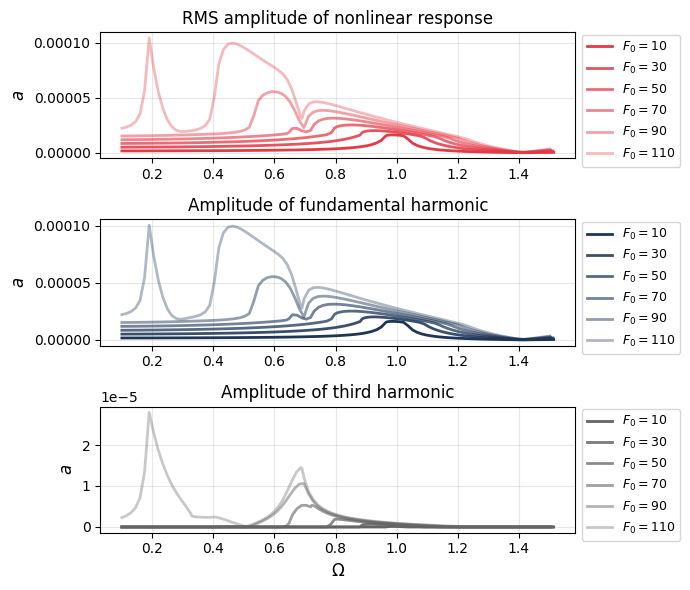

In [131]:
import json
import matplotlib.pyplot as plt


with open("../data/Jenkins_superharmonics.json", "r") as f:
    entries = json.load(f)

fig, ax = plt.subplots(3, 1, figsize=(7, 6))

for i, entry in enumerate(entries):
    if entry['force'] % 20:
        ax[0].plot(entry['freq_ratio'], entry['Q_nl'], color='#e63946', lw=2.0, alpha=1 - 0.065*i, label=rf'$F_0 = {entry["force"]}$')
        ax[1].plot(entry['freq_ratio'], entry['Q1'], color='#1D3557', lw=2.0, alpha=1 - 0.065*i, label=rf'$F_0 = {entry["force"]}$')
        ax[2].plot(entry['freq_ratio'], entry['Q3'], color='#646464', lw=2.0, alpha=1 - 0.065*i, label=rf'$F_0 = {entry["force"]}$')

ax[2].set_xlabel(r'$\Omega$', fontsize=12)
ax[0].set_ylabel(r'$a$', fontsize=12)
ax[1].set_ylabel(r'$a$', fontsize=12)
ax[2].set_ylabel(r'$a$', fontsize=12)
ax[0].set_title('RMS amplitude of nonlinear response', fontsize=12)
ax[1].set_title('Amplitude of fundamental harmonic', fontsize=12)
ax[2].set_title('Amplitude of third harmonic', fontsize=12)
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)
ax[2].grid(True, alpha=0.3)
ax[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1., 1.03))
ax[1].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1., 1.03))
ax[2].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1., 1.03))
plt.tight_layout()
plt.show()